# Q30 conditioning — did interaction-only conditioning steer the basin?

**The question this campaign tests:** when we re-diffuse *only the peptide* inside a fixed pMHC-TCR
complex, conditioned on specific interactions (Q30α, CDR3β-Phe, the A/B-pocket N-anchor, an
N-terminal sliding window), do the rebuilt backbones come **off the toGIG≈toDRG diagonal and into a
basin** — or do they drift equidistant from both (the prior failure)? This is **not** generic
structure QC.

**Make-or-break — the frame.** Every design is superposed on the **MHC β-sheet groove-floor Cα only**
(helices and the mobile α2 short arm His145–Val152 excluded; 6AM5↔6AMU floor RMSD ≈ 0.21 Å). Peptide
Cα-RMSD is then measured to **three** references — a single reference cannot resolve register:
`GIG` (6AM5, P10 F-pocket), `DRG_shift` (6AMU, P9 F-pocket), `DRG_unshift` (6AMT, excluded from seeding).

Arms: **fpocket** (Q30+floor F-pocket, prior), **tcr** (Q30α+Phe-β), **apoc** (+A/B-pocket N-anchor),
**nslide** (N-terminal window scan, motif-scaffold).

In [1]:
import sys, importlib, warnings; warnings.filterwarnings("ignore")
sys.path.insert(0, "/home/ubuntu/if-mhc/py")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import q30_analysis as Q; importlib.reload(Q)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
ARMS = ["fpocket", "tcr", "apoc", "nslide"]
ACOL = {"fpocket":"#9e9e9e","tcr":"#1f77b4","apoc":"#d62728","nslide":"#2ca02c"}
df, CO = Q.load_all(ARMS)
print(f"{len(df)} designs | coords {CO.shape} | refs: GIG,DRG_shift,DRG_unshift")
df.groupby(["arm","pid"]).size()

286 designs | coords (286, 10, 3) | refs: GIG,DRG_shift,DRG_unshift


arm      pid 
apoc     6AM5    52
         6AMU    56
fpocket  6AM5    23
         6AMU    23
nslide   6AM5    12
         6AMU    12
tcr      6AM5    52
         6AMU    56
dtype: int64

## 1 · Headline — GIG vs DRG basin scatter (floor frame)
The correct headline object. Points on the `y=x` diagonal = drift (no basin selected); points pulled
into a corner = a basin was chosen. Green box = seated (`min(toGIG,toDRG) < 4 Å`).

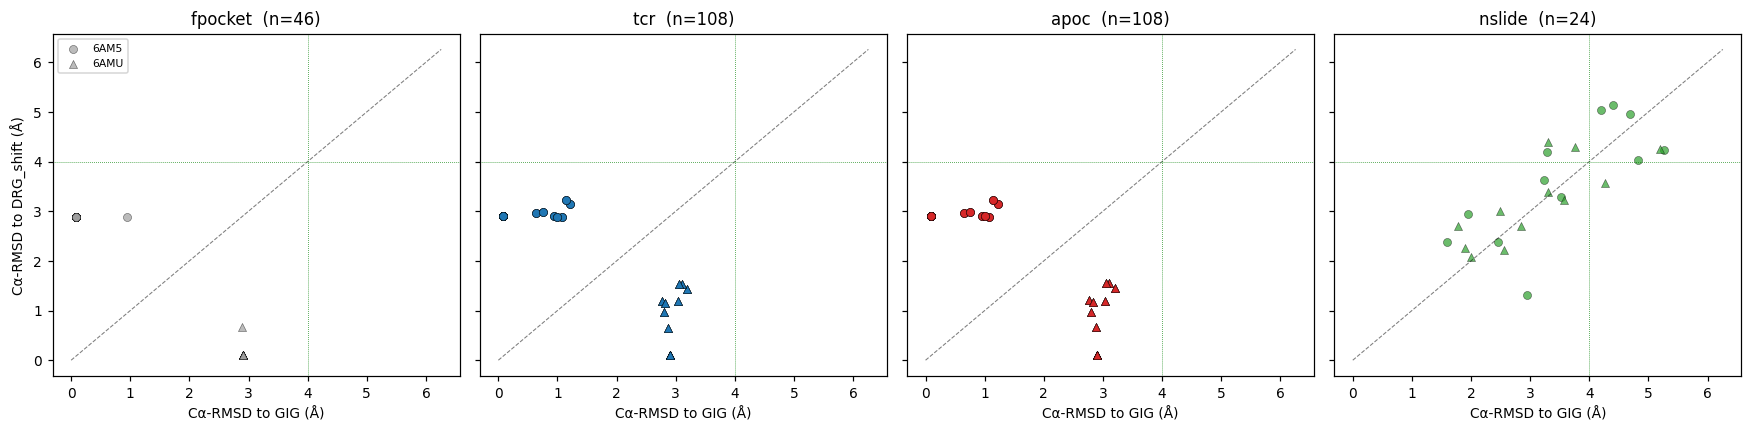

In [2]:
fig, axes = plt.subplots(1, len(ARMS), figsize=(4*len(ARMS), 4), sharex=True, sharey=True)
for ax, arm in zip(np.atleast_1d(axes), ARMS):
    s = df[df.arm == arm]
    if len(s):
        for pid, mk in [("6AM5","o"),("6AMU","^")]:
            ss = s[s.pid == pid]
            ax.scatter(ss.to_GIG, ss.to_DRG_shift, s=28, marker=mk, alpha=.7,
                       c=ACOL[arm], edgecolor="k", linewidth=.3, label=pid)
    lim = 1 + np.nanmax([df.to_GIG.max(), df.to_DRG_shift.max()]) if len(df) else 12
    ax.plot([0,lim],[0,lim],"k--",lw=.7,alpha=.5); ax.axhline(4,c="g",lw=.5,ls=":"); ax.axvline(4,c="g",lw=.5,ls=":")
    ax.set_title(f"{arm}  (n={len(s)})"); ax.set_xlabel("Cα-RMSD to GIG (Å)")
np.atleast_1d(axes)[0].set_ylabel("Cα-RMSD to DRG_shift (Å)"); np.atleast_1d(axes)[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

**Quantified:** fraction seated, fraction off-diagonal, and basin split per arm × epitope.

In [3]:
def quant(s):
    return pd.Series(dict(n=len(s), seated=round(s.seated.mean(),2) if len(s) else np.nan,
        off_diag_med=round(s.off_diagonal.median(),2) if len(s) else np.nan,
        pct_GIG=round((s.basin=="GIG").mean(),2) if len(s) else np.nan,
        toGIG_med=round(s.to_GIG.median(),2) if len(s) else np.nan,
        toDRG_med=round(s.to_DRG_shift.median(),2) if len(s) else np.nan))
df.groupby(["arm","pid"]).apply(quant)

n  seated  off_diag_med  pct_GIG  toGIG_med  toDRG_med
arm     pid                                                            
apoc    6AM5  52.0    1.00          2.31     1.00       0.65       2.90
        6AMU  56.0    0.86          2.03     0.00       2.90       0.82
fpocket 6AM5  23.0    1.00          2.81     1.00       0.08       2.89
        6AMU  23.0    1.00          2.81     0.00       2.91       0.10
nslide  6AM5  12.0    0.08          0.80     0.58       3.40       3.83
        6AMU  12.0    0.00          0.43     0.58       3.07       3.11
tcr     6AM5  52.0    1.00          2.32     1.00       0.64       2.90
        6AMU  56.0    0.86          2.04     0.00       2.90       0.81

## 2 · Three-reference RMSD
A single backbone can't resolve register; comparing to GIG / DRG_shift / DRG_unshift shows *which*
register (and whether the unshifted DRG, though never seeded, is nearest).

In [4]:
cols = [c for c in ["to_GIG","to_DRG_shift","to_DRG_unshift"] if c in df]
g = df.groupby(["arm","pid"])[cols].median().round(2)
g["nearest_ref"] = df.groupby(["arm","pid"]).apply(
    lambda s: pd.Series(np.median(s[cols].values,0), index=cols).idxmin())
g

to_GIG  to_DRG_shift  to_DRG_unshift     nearest_ref
arm     pid                                                       
apoc    6AM5    0.65          2.90            1.86          to_GIG
        6AMU    2.90          0.82            2.72    to_DRG_shift
fpocket 6AM5    0.08          2.89            2.05          to_GIG
        6AMU    2.91          0.10            2.94    to_DRG_shift
nslide  6AM5    3.40          3.83            3.80          to_GIG
        6AMU    3.07          3.11            3.07  to_DRG_unshift
tcr     6AM5    0.64          2.90            1.86          to_GIG
        6AMU    2.90          0.81            2.72    to_DRG_shift

## 3 · N- vs C-terminal split RMSD (highest-signal addition)
The register is a **C-terminal** event; the N-terminus is what we conditioned. If conditioning works,
the N-half should track the target while the C-half is where the basin is (or isn't) resolved.

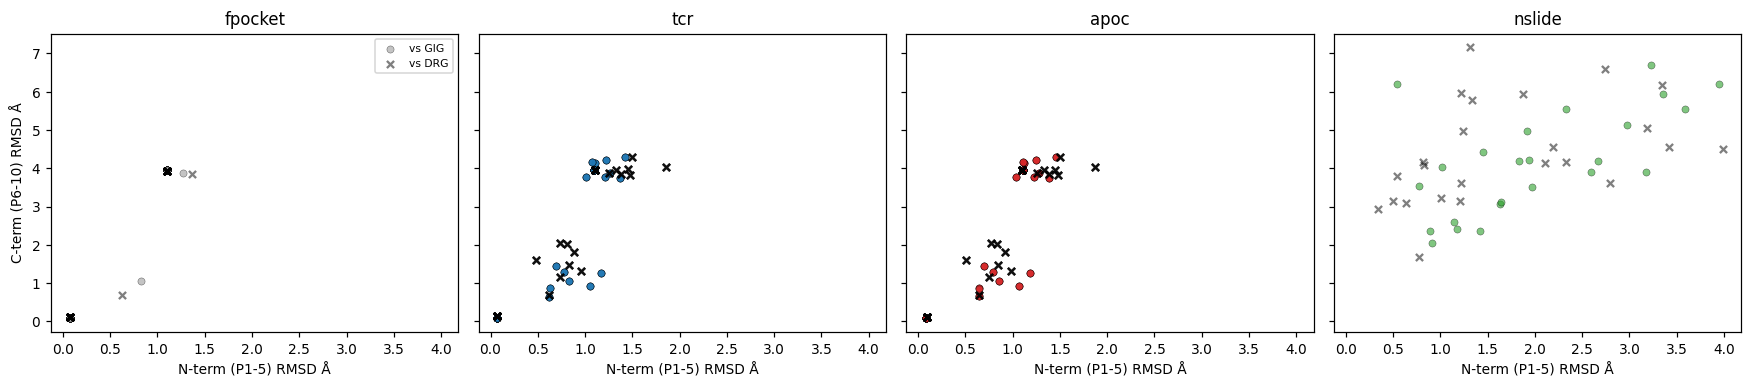

,Nterm_GIG,Cterm_GIG,Nterm_DRG_shift,Cterm_DRG_shift
arm,,,,
apoc,1.10,3.76,0.99,2.05
fpocket,0.97,2.46,0.87,2.27
nslide,1.87,4.11,1.27,4.16
tcr,1.08,3.76,0.96,2.05


In [5]:
fig, axes = plt.subplots(1, len(ARMS), figsize=(4*len(ARMS), 3.6), sharex=True, sharey=True)
for ax, arm in zip(np.atleast_1d(axes), ARMS):
    s = df[df.arm == arm]
    if len(s):
        ax.scatter(s.Nterm_GIG, s.Cterm_GIG, s=22, c=ACOL[arm], alpha=.6, edgecolor="k", linewidth=.3, label="vs GIG")
        ax.scatter(s.Nterm_DRG_shift, s.Cterm_DRG_shift, s=22, marker="x", c="k", alpha=.5, label="vs DRG")
    ax.set_title(arm); ax.set_xlabel("N-term (P1-5) RMSD Å")
np.atleast_1d(axes)[0].set_ylabel("C-term (P6-10) RMSD Å"); np.atleast_1d(axes)[0].legend(fontsize=7)
plt.tight_layout(); plt.show()
df.groupby("arm")[[c for c in ["Nterm_GIG","Cterm_GIG","Nterm_DRG_shift","Cterm_DRG_shift"] if c in df]].median().round(2)

## 4 · Contact satisfaction — did conditioning actually work? (the direct test)
Per design, min **Cβ–Cβ** distance from the peptide to each conditioned residue (backbone-only
designs → Cβ, RFdiffusion's hotspot convention; ≤8 Å = contact formed). This closes the loop: did the
rebuilt backbone form the contacts we conditioned on?

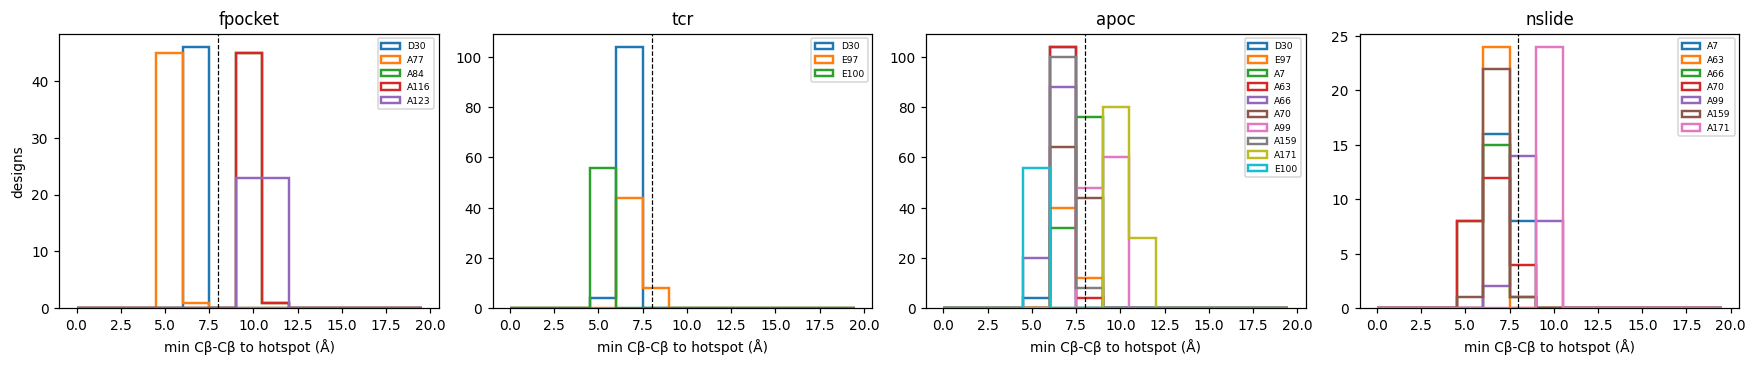

arm
apoc       0.75
fpocket    0.40
nslide     0.72
tcr        1.00
Name: frac hotspots ≤8Å, dtype: float64

In [6]:
fig, axes = plt.subplots(1, len(ARMS), figsize=(4*len(ARMS), 3.4))
for ax, arm in zip(np.atleast_1d(axes), ARMS):
    s = df[df.arm == arm]
    if not len(s):
        ax.set_title(f"{arm} (n=0)"); continue
    byres = {}
    for d in s.contacts:
        for k, v in (d or {}).items(): byres.setdefault(k, []).append(v)
    for k, vals in byres.items():
        ax.hist(vals, bins=np.arange(0,20,1.5), histtype="step", lw=1.6, label=k)
    ax.axvline(8, c="k", ls="--", lw=.8); ax.set_title(f"{arm}"); ax.set_xlabel("min Cβ-Cβ to hotspot (Å)")
    ax.legend(fontsize=6)
np.atleast_1d(axes)[0].set_ylabel("designs"); plt.tight_layout(); plt.show()
df.groupby("arm").contacts_frac.mean().round(2).rename("frac hotspots ≤8Å")

## 5 · F-pocket register readout (RMSD-independent)
Which peptide Cα sits at the F-pocket centroid: **P10 = unshifted / GIG-like**, **P9 = DRG-shifted**.
The single cleanest register number.

fpocket_pos   7   8   9   10
arm     pid                 
apoc    6AM5   0   0   0  52
        6AMU   0   0  56   0
fpocket 6AM5   0   0   0  23
        6AMU   0   0  23   0
nslide  6AM5   0   3   4   5
        6AMU   1   2   1   8
tcr     6AM5   0   0   0  52
        6AMU   0   0  56   0

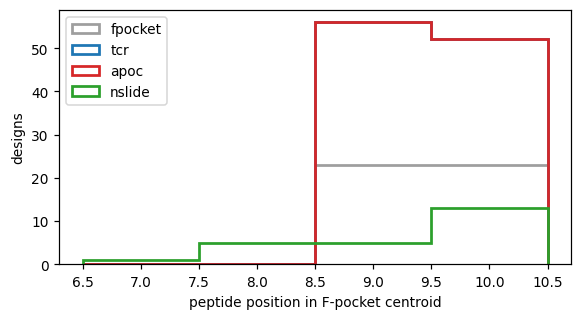

In [7]:
fp = df.groupby(["arm","pid"]).fpocket_pos.value_counts().unstack(fill_value=0)
display(fp)
fig, ax = plt.subplots(figsize=(6,3))
for arm in ARMS:
    s = df[df.arm==arm]
    if len(s): ax.hist(s.fpocket_pos, bins=np.arange(6.5,11.5,1), histtype="step", lw=1.8, label=arm, color=ACOL[arm])
ax.set_xlabel("peptide position in F-pocket centroid"); ax.set_ylabel("designs"); ax.legend(); plt.show()

## 6 · Clustering + aggregate trace overlays
Cluster on pairwise peptide Cα-RMSD (already in the floor frame → direct). Report cluster count,
population, and each cluster's mean RMSD to GIG/DRG; overlay each cluster's Cα traces with the three
references (the quantified version of the trace panels).

In [8]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
N = len(CO)
if N >= 3:
    D = np.zeros((N,N))
    for i in range(N):
        D[i,i+1:] = np.sqrt(((CO[i]-CO[i+1:])**2).sum(-1).mean(-1))
    D += D.T
    Z = linkage(squareform(D, checks=False), method="average")
    cl = fcluster(Z, t=1.5, criterion="distance")   # 1.5 Å average-linkage cut
    df["cluster"] = cl
    summ = df.groupby("cluster").agg(n=("seated","size"), toGIG=("to_GIG","mean"),
            toDRG=("to_DRG_shift","mean"), arms=("arm", lambda x:",".join(sorted(set(x))))).round(2)
    summ = summ.sort_values("n", ascending=False)
    display(summ.head(12))
    print(f"{len(summ)} clusters at 1.5Å")
else:
    df["cluster"] = 1; summ = None; print("too few designs to cluster yet")

,n,toGIG,toDRG,arms
cluster,,,,
6,136,2.93,0.64,"apoc,fpocket,nslide,tcr"
9,127,0.48,2.94,"apoc,fpocket,tcr"
8,4,2.44,2.76,nslide
3,2,5.04,4.13,nslide
11,2,1.95,2.17,nslide
4,1,4.26,3.58,nslide
1,1,4.39,5.15,nslide
2,1,3.30,4.40,nslide
7,1,2.56,2.22,nslide


20 clusters at 1.5Å


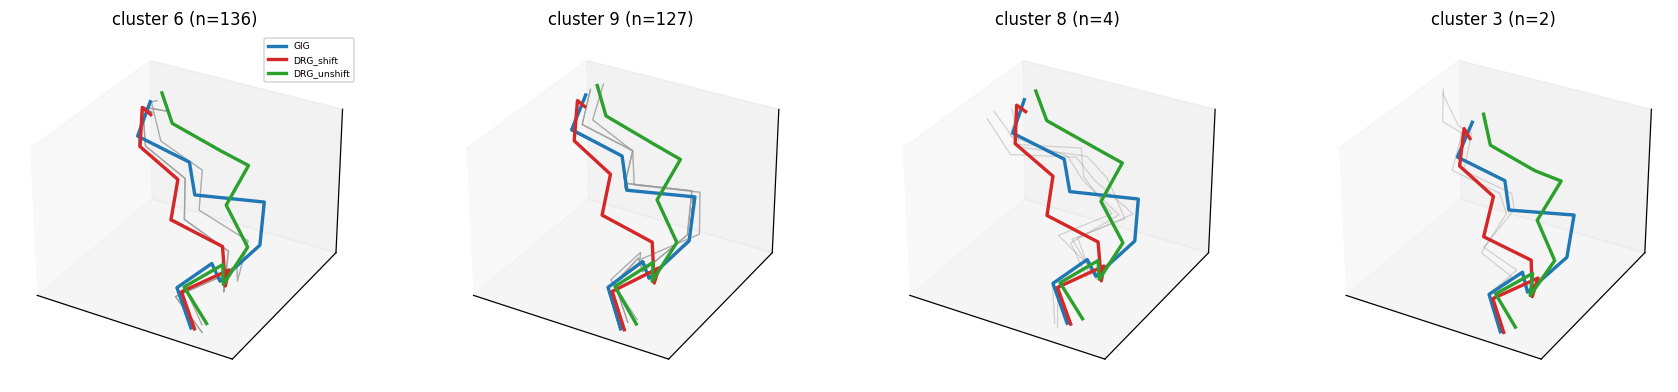

In [9]:
if len(CO) >= 3 and summ is not None:
    top = summ.head(min(4, len(summ))).index
    fig = plt.figure(figsize=(4*len(top), 3.6))
    for k, cid in enumerate(top):
        ax = fig.add_subplot(1, len(top), k+1, projection="3d")
        for i in df.index[df.cluster == cid][:30]:
            p = CO[i]; ax.plot(p[:,0],p[:,1],p[:,2], color="0.6", alpha=.4, lw=.8)
        for nm, c in [("GIG","#1f77b4"),("DRG_shift","#d62728"),("DRG_unshift","#2ca02c")]:
            r = Q.REFS[nm]
            if len(r)==10: ax.plot(r[:,0],r[:,1],r[:,2], color=c, lw=2.2, label=nm)
        ax.set_title(f"cluster {cid} (n={summ.loc[cid,'n']})"); ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
        if k==0: ax.legend(fontsize=6)
    plt.tight_layout(); plt.show()

## 7 · Per-residue RMSF (tight bundle vs spray)
Positional spread of each peptide Cα across the ensemble in the floor frame. Expect **low at the
conditioned N-terminus / anchors, high at the free C-terminus** — the number behind a tight bundle
vs a spray.

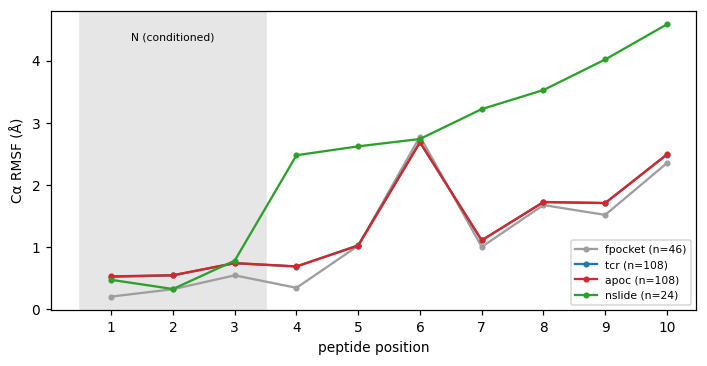

In [10]:
fig, ax = plt.subplots(figsize=(6.5,3.4))
for arm in ARMS:
    idx = df.index[df.arm == arm]
    if len(idx) >= 2:
        sub = CO[idx]; rmsf = np.sqrt(((sub - sub.mean(0))**2).sum(-1).mean(0))
        ax.plot(range(1,11), rmsf, "-o", ms=3, color=ACOL[arm], label=f"{arm} (n={len(idx)})")
ax.set_xlabel("peptide position"); ax.set_ylabel("Cα RMSF (Å)"); ax.set_xticks(range(1,11)); ax.legend(fontsize=7)
ax.axvspan(0.5,3.5,color="0.9",zorder=0); ax.text(2,ax.get_ylim()[1]*.9,"N (conditioned)",fontsize=7,ha="center")
plt.tight_layout(); plt.show()

## 8 · Physical sanity filter
Cα–Cα virtual bond lengths (ideal ~3.8 Å; flag <3.0 or >4.5) and self-clashes (non-adjacent
Cα < 3.0 Å). Broken designs (the tails flying off) are flagged and should be excluded from the
basin claims above.

In [11]:
san = df.groupby("arm").agg(n=("broken","size"), bad_bond=("bad_bond","sum"),
        clash=("clash","sum"), broken=("broken","sum"))
san["pct_broken"] = (100*san.broken/san.n).round(1)
display(san)
if df.broken.sum(): display(df[df.broken==1][["arm","seed","cond","idx","min_ref","file"]].head(20))
else: print("no broken geometry flagged")

,n,bad_bond,clash,broken,pct_broken
arm,,,,,
apoc,108,0,0,0,0.0
fpocket,46,0,0,0,0.0
nslide,24,0,0,0,0.0
tcr,108,0,0,0,0.0


no broken geometry flagged


## 9 · Verdict
Per arm, on **clean** designs only: did conditioning pull backbones off the diagonal into a basin, and
were the conditioned contacts formed?

In [12]:
ok = df[df.broken == 0]
verdict = ok.groupby("arm").agg(n=("seated","size"), pct_seated=("seated","mean"),
        off_diag_med=("off_diagonal","median"), contacts=("contacts_frac","mean"),
        fpocket_mode=("fpocket_pos", lambda x: x.mode().iloc[0] if len(x) else np.nan)).round(2)
display(verdict)
print("Reading: high off_diag_med + high pct_seated + high contacts = conditioning steered a basin.")
print("NOTE: while arms are still running these are dominated by near-native low-T/crystal echoes;")
print("re-run this notebook as relaxed-seed and higher-noise designs accumulate.")

,n,pct_seated,off_diag_med,contacts,fpocket_mode
arm,,,,,
apoc,108,0.93,2.23,0.75,9
fpocket,46,1.00,2.81,0.40,9
nslide,24,0.04,0.61,0.72,10
tcr,108,0.93,2.24,1.00,9


Reading: high off_diag_med + high pct_seated + high contacts = conditioning steered a basin.
NOTE: while arms are still running these are dominated by near-native low-T/crystal echoes;
re-run this notebook as relaxed-seed and higher-noise designs accumulate.
